In [ ]:
import os
os.chdir('/home/yunwei/SNAIL/full_simulation copy/binonmial_code')
print("Working directory:", os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import colorednoise as cn
import qutip as qt
from noise_generator import GenerateNoise
from hamiltonian_generator import Hamiltonian
from system import *
from joblib import Parallel, delayed
from scipy.optimize import curve_fit

class Simulation:
    def __init__(self, A, initial_state, t_max, sample_rate, num_realizations, S0):
        self.A = A
        self.initial_state = initial_state
        
        # System parameters
        self.phi_ex = 0.2
        self.Ej = 30.19 
        self.Ec = 0.1

        # Setup Hamiltonian for optimal frequency calculation
        self.sc = Hamiltonian(self.phi_ex, self.Ej, self.Ec, [5,10])
        self.optimal_omega,rate = self.sc.optimal_omegad(self.A)
        self.optimal_omega = self.optimal_omega*2*np.pi
        self.sc = Hamiltonian(self.phi_ex, self.Ej, self.Ec, [3,5]) 
        self.sample_rate = sample_rate
        self.num_realizations = num_realizations
        self.S0 = S0
        self.t_max = t_max
        self.cplus_state, self.kick_and_sigmax, self.get_projector = self.sc.setup_floquet_system(A,self.optimal_omega)
        self.detuning = np.real(self.sc.H)[2,2] - self.optimal_omega

    def noise_check(self, if_plot=False):
        # Initialize arrays to store results
        tnoise_max = int(self.t_max)             # number of samples
        relative_PSD_strength = self.S0**2
        ifwhite = False               # True for white noise, False for 1/f noise
        
        gn = GenerateNoise(self.sample_rate, tnoise_max, relative_PSD_strength, self.num_realizations, ifwhite)
        trajs = gn.generate_colored_noise()
        self.trajs = trajs
        if if_plot:
            gn.analyze_noise_psd(trajs)
    
    def operators(self):
        sds = self.sc.noise
        sop = self.sc.s
        H_control = self.sc.H_control
        H0 = self.sc.H
        diagonal_energies = np.diag(self.sc.H) - self.sc.H[0,0]
        H0 = np.diag(diagonal_energies)
        sds = qt.Qobj(sds)
        sop = qt.Qobj(sop)
        H_control = qt.Qobj(H_control)
        H0 = qt.Qobj(H0)
        return sds, sop, H_control, H0,

    def I_control(self, ramp_time, T, amplitude=1.0):
        if ramp_time <= 0 or T < 2 * ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and T >= 2 * ramp_time")

        def pulse(t):
            t = np.asarray(t)
            result = np.zeros_like(t, dtype=float)

            # Sin-squared ramp up
            mask1 = (t > 0) & (t < ramp_time)
            result[mask1] = amplitude * np.sin((np.pi / 2) * (t[mask1] / ramp_time))**2

            # Flat top
            mask2 = (t >= ramp_time) & (t <= T - ramp_time)
            result[mask2] = amplitude

            # Sin-squared ramp down
            mask3 = (t > T - ramp_time) & (t < T)
            result[mask3] = amplitude * np.sin((np.pi / 2) * (1 - (t[mask3] - (T - ramp_time)) / ramp_time))**2

            if result.shape == ():
                return float(result)
            return result

        return pulse

    def Q_control(self, freq, ramp_time, T, amplitude=1.0):
        if ramp_time <= 0 or T < 2 * ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and T >= 2 * ramp_time")

        peak = amplitude * np.pi / (2 * ramp_time)

        def pulse_derivative(t):
            t = np.asarray(t)
            result = np.zeros_like(t, dtype=float)

            # Derivative of ramp up
            mask1 = (t > 0) & (t < ramp_time)
            result[mask1] = peak * np.sin(np.pi * t[mask1] / ramp_time)

            # Derivative of ramp down
            mask3 = (t > T - ramp_time) & (t < T)
            result[mask3] = -peak * np.sin(np.pi * (t[mask3] - (T - ramp_time)) / ramp_time)

            result = -result / freq

            if result.shape == ():
                return float(result)
            return result

        return pulse_derivative

    import numpy as np

    def A_function(self, freq, ramp_time, T, amplitude=1.0):
        if ramp_time <= 0 or T < 2 * ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and T >= 2 * ramp_time")

        deriv_peak = amplitude * np.pi / (2 * ramp_time)
        pi_over_2 = np.pi / 2
        pi_over_rt = np.pi / ramp_time
        inv_freq = 1.0 / freq

        def A(t):
            t = np.asarray(t, dtype=float)
            result = np.full_like(t, fill_value=0.0, dtype=float)

            # Use boolean masks once
            mask1 = (t > 0) & (t < ramp_time)
            mask2 = (t >= ramp_time) & (t <= T - ramp_time)
            mask3 = (t > T - ramp_time) & (t < T)

            # Ramp up calculations
            if np.any(mask1):
                ang1 = pi_over_2 * (t[mask1] / ramp_time)
                sin_ang1 = np.sin(ang1)
                I1 = amplitude * sin_ang1 * sin_ang1
                Q1 = -deriv_peak * np.sin(pi_over_rt * t[mask1]) * inv_freq
                result[mask1] = np.hypot(I1, Q1)  # More efficient for sqrt(I^2+Q^2)

            # Flat top amplitude is constant
            if np.any(mask2):
                result[mask2] = amplitude

            # Ramp down calculations
            if np.any(mask3):
                ang3 = pi_over_2 * (1 - (t[mask3] - (T - ramp_time)) / ramp_time)
                sin_ang3 = np.sin(ang3)
                I3 = amplitude * sin_ang3 * sin_ang3
                Q3 = deriv_peak * np.sin(pi_over_rt * (t[mask3] - (T - ramp_time))) * inv_freq
                result[mask3] = np.hypot(I3, Q3)

            if result.shape == ():
                return float(result)
            return result

        return A


    def phi_function(self, freq, ramp_time, T, amplitude=1.0):
        if ramp_time <= 0 or T < 2 * ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and T >= 2 * ramp_time")

        deriv_peak = amplitude * np.pi / (2 * ramp_time)
        pi_over_2 = np.pi / 2
        pi_over_rt = np.pi / ramp_time
        inv_freq = 1.0 / freq

        def phi(t):
            t = np.asarray(t, dtype=float)
            result = np.zeros_like(t, dtype=float)

            mask1 = (t > 0) & (t < ramp_time)
            mask2 = (t >= ramp_time) & (t <= T - ramp_time)
            mask3 = (t > T - ramp_time) & (t < T)

            # Ramp up phase
            if np.any(mask1):
                ang1 = pi_over_2 * (t[mask1] / ramp_time)
                sin_ang1 = np.sin(ang1)
                I1 = amplitude * sin_ang1 * sin_ang1
                Q1 = -deriv_peak * np.sin(pi_over_rt * t[mask1]) * inv_freq
                result[mask1] = np.arctan2(Q1, I1)

            # Plateau phase
            if np.any(mask2):
                result[mask2] = 0.0

            # Ramp down phase
            if np.any(mask3):
                ang3 = pi_over_2 * (1 - (t[mask3] - (T - ramp_time)) / ramp_time)
                sin_ang3 = np.sin(ang3)
                I3 = amplitude * sin_ang3 * sin_ang3
                Q3 = deriv_peak * np.sin(pi_over_rt * (t[mask3] - (T - ramp_time))) * inv_freq
                result[mask3] = np.arctan2(Q3, I3)

            if result.shape == ():
                return float(result)
            return result

        return phi

    def A_function_longtime(self, freq, ramp_time, T, total_duration, amplitude=1.0):
        """
        Extended amplitude function: ramp-up (0 to ramp_time) then constant until total_duration.
        
        Parameters:
        - freq: frequency for DRAG correction
        - ramp_time: duration of the ramp-up phase
        - T: original pulse duration (used for ramp shape calculation)
        - total_duration: total duration of the extended pulse
        - amplitude: peak amplitude (default 1.0)
        """
        if ramp_time <= 0 or total_duration < ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and total_duration >= ramp_time")

        deriv_peak = amplitude * np.pi / (2 * ramp_time)
        pi_over_2 = np.pi / 2
        pi_over_rt = np.pi / ramp_time
        inv_freq = 1.0 / freq

        def A(t):
            t = np.asarray(t, dtype=float)
            result = np.full_like(t, fill_value=0.0, dtype=float)

            # Ramp up phase: 0 < t < ramp_time
            mask1 = (t > 0) & (t < ramp_time)
            # Constant phase: ramp_time <= t <= total_duration
            mask2 = (t >= ramp_time) & (t <= total_duration)

            # Ramp up calculations (same as A_function)
            if np.any(mask1):
                ang1 = pi_over_2 * (t[mask1] / ramp_time)
                sin_ang1 = np.sin(ang1)
                I1 = amplitude * sin_ang1 * sin_ang1
                Q1 = -deriv_peak * np.sin(pi_over_rt * t[mask1]) * inv_freq
                result[mask1] = np.hypot(I1, Q1)

            # Constant amplitude after ramp
            if np.any(mask2):
                result[mask2] = amplitude

            if result.shape == ():
                return float(result)
            return result

        return A

    def phi_function_longtime(self, freq, ramp_time, T, total_duration, amplitude=1.0):
        """
        Extended phase function: ramp-up phase (0 to ramp_time) then zero until total_duration.
        
        Parameters:
        - freq: frequency for DRAG correction
        - ramp_time: duration of the ramp-up phase
        - T: original pulse duration (used for ramp shape calculation)
        - total_duration: total duration of the extended pulse
        - amplitude: peak amplitude (default 1.0)
        """
        if ramp_time <= 0 or total_duration < ramp_time:
            raise ValueError("Invalid parameters: Ensure ramp_time > 0 and total_duration >= ramp_time")

        deriv_peak = amplitude * np.pi / (2 * ramp_time)
        pi_over_2 = np.pi / 2
        pi_over_rt = np.pi / ramp_time
        inv_freq = 1.0 / freq

        def phi(t):
            t = np.asarray(t, dtype=float)
            result = np.zeros_like(t, dtype=float)

            # Ramp up phase: 0 < t < ramp_time
            mask1 = (t > 0) & (t < ramp_time)
            # Constant phase: ramp_time <= t <= total_duration (phi = 0)
            mask2 = (t >= ramp_time) & (t <= total_duration)

            # Ramp up phase calculation (same as phi_function)
            if np.any(mask1):
                ang1 = pi_over_2 * (t[mask1] / ramp_time)
                sin_ang1 = np.sin(ang1)
                I1 = amplitude * sin_ang1 * sin_ang1
                Q1 = -deriv_peak * np.sin(pi_over_rt * t[mask1]) * inv_freq
                result[mask1] = np.arctan2(Q1, I1)

            # Plateau phase: phi = 0
            if np.any(mask2):
                result[mask2] = 0.0

            if result.shape == ():
                return float(result)
            return result

        return phi



t_max = 100000
A = 0e-3 * 2 * np.pi
initial_state = []
ramp_time = 100
num_realizations = 100
S0 = 1e-5
sample_rate = 1        # per ns
g = 0.025*2*np.pi
sim = Simulation(A,initial_state, t_max,sample_rate, num_realizations,S0)
ket0 = qt.Qobj(sim.kick_and_sigmax(0)[0][:,0], dims=[[3, 5], [1, 1]])
ket2 = qt.Qobj(sim.kick_and_sigmax(0)[0][:,2], dims=[[3, 5], [1, 1]])
ket4 = qt.Qobj(sim.kick_and_sigmax(0)[0][:,4], dims=[[3, 5], [1, 1]])
ket0L = (ket0 + ket4).unit()
ket1L = ket2
psi_vec = (ket0L + ket1L).unit()

Working directory: /home/yunwei/SNAIL/full_simulation copy/binonmial_code
original_rate (omega_s) = 2.324095e+00, min_rate = 2.324095e+00
optimal_omega_d = 6.152015 GHz, detuning = 0.0000 MHz


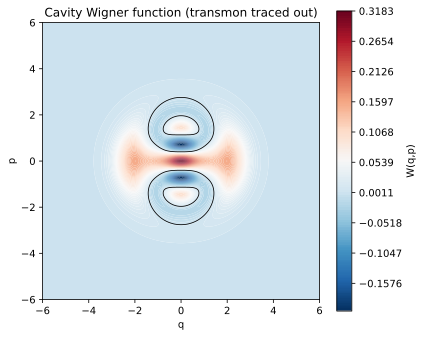

In [50]:
rho_tc = qt.ket2dm(psi_vec)
# Trace out transmon (subsystem 0), keep cavity (subsystem 1)
rho_cav = rho_tc.ptrace(1)

# Wigner plot for cavity
x = np.linspace(-6, 6, 201)
W = qt.wigner(rho_cav, x, x)

fig, ax = plt.subplots(figsize=(6, 5))
levels = np.linspace(W.min(), W.max(), 120)
cf = ax.contourf(x, x, W, levels=levels, cmap="RdBu_r")
ax.contour(x, x, W, levels=[0], colors="k", linewidths=0.8)
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_title("Cavity Wigner function (transmon traced out)")
ax.set_aspect("equal")
fig.colorbar(cf, ax=ax, label="W(q,p)")
plt.tight_layout()
plt.show()